In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as st

## Задача 1

1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Сформировать новый датасет из отсортированного в алфавитном порядке списка из трёх факторов в количественной шкале: ингредиент_2, ингредиент_1, вес

3) Рассчитать матрицу корреляций для количественных данных. Использовать метод корреляций для случая нормального распределения данных.

In [ ]:
df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df_new = df[['ингредиент_2', 'ингредиент_1', 'вес']]
df_new = df_new.reindex(columns = sorted(df_new.columns.tolist()))
print(df_new.corr())

,вес,оператор_линии,ингредиент_1,номер_смены,номер_конвейера,ингредиент_2,брак
0,61.7,2,250.9,2,1,6.3,Годен
1,58.6,2,275.7,1,2,6.7,Брак
2,61.6,1,266.4,1,1,16.7,Брак


## Задача 2

1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Сгруппировать по номеру партии (столбцу key) и найти сумму по каждому фактору.

3) Рассчитать матрицу линейных корреляций между количественными данными для новой таблицы. Использовать метод корреляции для случая ненормального распределения данных.

4) Вывести на экран матрицу корреляций. Если коэффициент корреляции менее 0.85 по модулю, то такие значения в матрице не должны выводится (вместо них должны стоять NaN).

In [ ]:
df = pd.read_csv('qq3.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
part = df.groupby('key').agg('sum')
correlated = part.corr(method='spearman').applymap(lambda x: None if abs(x) < 0.85 else x)
print(correlated)

                   вес  ингредиент_1  ингредиент_2
вес           1.000000     -0.002662      0.664944
ингредиент_1 -0.002662      1.000000      0.091276
ингредиент_2  0.664944      0.091276      1.000000


### Дополнительно

## Задача 3

1) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

2) Сформировать датасет из отсортированного в алфавитном порядке списка количественного фактора ингредиент_1 и качественного фактора брак.

3) Используя теорию урока, выбрать метод и рассчитать по новому датасету взаимосвязь между данными.

4) Результат вывести в виде числа с округлением до четвёртого знака.

In [ ]:
import pandas as pd
import numpy as np
from math import *

df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df_sorted = df[['брак', 'ингредиент_1']]

inside = 0
out = 0
main_sr = df['ингредиент_1'].mean()

for name, group in df_sorted.groupby('брак')['ингредиент_1']:
    inside_group = 0
    arr = list(group)
    for elem in arr:
        inside_group += (elem - group.mean()) ** 2
    out += len(arr) * (group.mean() - main_sr) ** 2
    inside += inside_group

result = round(m.sqrt(out / (inside + out)), 4)
print(result)

0.0509


## Задача 4

1) Сформировать список из количественного фактора вес и качественного фактора брак
2) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

3) Сформировать новый датасет, используя условия отбора :
- номер_конвейера = 1
- номер_смены = 2

4) Сформировать датасет из отсортированного в алфавитном порядке списка количественного фактора вес и качественного фактора брак.
5) Используя теорию урока, выбрать метод и рассчитать по новому датасету взаимосвязь между данными в разных шкалах.

6) Результат вывести с округлением до четвёртого знака.

In [ ]:
df = pd.read_csv(PATH_OUT + '\\qq_csv.csv',sep=',', encoding='cp1251', skipinitialspace=True)
df.head(3)

,вес,оператор_линии,ингредиент_1,номер_смены,новер_конвейера,ингредиент_2,брак
0,61.7,2,250.9,2,1,6.3,Годен
1,58.6,2,275.7,1,2,6.7,Брак
2,53.6,2,280.6,2,1,7.5,Брак


In [ ]:
import pandas as pd
import math as m


df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df[(df['номер_конвейера'] == 1) & (df['номер_смены'] == 2)]
df_sorted = df[['брак', 'вес']]

inside = 0
out = 0
main_sr = df['весa'].mean()

for name, group in df_sorted.groupby('брак')['вес']:
    inside_group = 0
    arr = list(group)
    for elem in arr:
        inside_group += (elem - group.mean()) ** 2
    out += len(arr) * (group.mean() - main_sr) ** 2
    inside += inside_group

result = round(m.sqrt(out / (inside + out)), 4)
print(result)

0.1774


## Задача 5

1) Сформировать список из количественного фактора вес и качественного фактора брак.
2) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить - кириллица

4) Сформировать новый датасет, используя условия отбора:
- ингредиент_1 < 270
- номер_смены = 2


3) Сформировать датасет из списка качественных факторов: оператор_линии и брак.

4) Используя теорию урока, выбрать метод и рассчитать по новому датасету корреляцию для поиска взаимосвязи между данными в одинаковых качественных шкалах.

5) Результат вывести в виде числа, с округлением до четвёртого знака.

In [ ]:
df = pd.read_csv(PATH_OUT + '\\qq_csv.csv',sep=',', encoding='cp1251', skipinitialspace=True)
df.head(3)

,вес,оператор_линии,ингредиент_1,номер_смены,новер_конвейера,ингредиент_2,брак
0,61.7,2,250.9,2,1,6.3,Годен
1,58.6,2,275.7,1,2,6.7,Брак
2,53.6,2,280.6,2,1,7.5,Брак


In [ ]:
df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df_new = df[(df['номер_смены'] == 2) & (df['ингредиент_1'] < 270)]
val = df_new[['оператор_линии', 'брак']]
con_table = pd.crosstab(val['оператор_линии'], val['брак'])
chi2 = chi2_contingency(con_table)[0]
n = val.shape[0]
min_dim = min(val.shape[0], val.shape[1])
cramers = m.sqrt(chi2 / (n * (min_dim - 1)))
print(round(cramers, 4))

оператор_линии  брак 
2               Годен    12
1               Брак      3
                Годен     3
2               Брак      1
Name: count, dtype: int64

In [ ]:
0.2829

## Задача 6

1)Загрузить файл, удалить строки с пропущенными значениями
2) Перевести название колонок в стандарт PEP8:
- перевести в нижний регистр
- пробелы между словами заменить на _
- язык сохранить кириллица

3) На основе фактора ингредиент 1 сформировать новый фактор ингредиент_кат, используя условия:
- если менее равно 270, то группа менее_270
- если более 270, то группа более_270

4) Сформировать новый датасет из нового фактора ингредиент_кат и качественного фактора брак
5) Используя теорию урока, выбрать метод и рассчитать по новому датасету корреляцию для поиска взаимосвязи между данными в одинаковых качественных шкалах.

6) Результат вывести в виде числа, с округлением до четвёртого знака.

In [ ]:
df = pd.read_csv(PATH_OUT + '\\qq_csv.csv',sep=',', encoding='cp1251', skipinitialspace=True)
df.head(3)

,вес,оператор_линии,ингредиент_1,номер_смены,новер_конвейера,ингредиент_2,брак
0,61.7,2,250.9,2,1,6.3,Годен
1,58.6,2,275.7,1,2,6.7,Брак
2,53.6,2,280.6,2,1,7.5,Брак


In [ ]:
df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['ингредиент_кат'] = ['менее_270' if x <= 270 else 'более_270' for x in df['ингредиент_1']]
val = df[['ингредиент_кат', 'брак']]
con_table = pd.crosstab(val['ингредиент_кат'], val['брак'])
chi2 = chi2_contingency(con_table)[0]
n = val.shape[0]
min_dim = min(val.shape[0], val.shape[1])
cramers = m.sqrt(chi2 / (n * (min_dim - 1)))
print(round(cramers, 4))

0.4385


## Задача 7

df = pd.read_csv(PATH_OUT + '\\qq_csv.csv',sep=',', encoding='cp1251', skipinitialspace=True).dropna()
df.columns = df.columns.str.lower().str.replace(' ', '_')
df

ингредиент_1


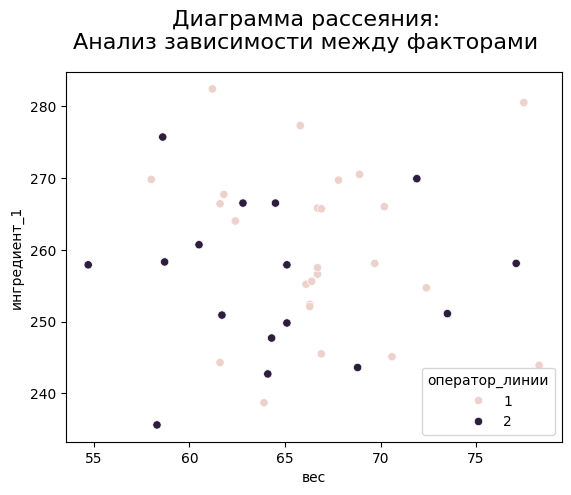

In [ ]:
df = pd.read_csv('qq.csv', sep=',', encoding='cp1251', skipinitialspace=True)
df = df.dropna()
name = input()
sns.scatterplot(df, x='вес', y=name, hue='оператор_линии')
plt.suptitle(
    'Диаграмма рассеяния:\nАнализ зависимости между факторами',
    fontsize=16,
    y=1.01
)
plt.savefig('target_3_7.png')
plt.show()